# CODE

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial import ConvexHull
from collections import Counter

In [4]:
# LENGTHS

# base = 120
# # proximal = 200
# # distal = 300

# P1 = np.array([0.0,  0.0])
# P2 = np.array([base, 0.0])

# print(f"base= {base}  proximal= {proximal}  distal= {distal}")
# print(f"max_reach= {proximal+distal:.0f}mm  b/l1={base/proximal:.3f}")

In [5]:
# MASS

MASS = {
    'R'    : (11.5 + 13)/1000,   # revolute endcap
    'horn' : (18)/1000,          # servo horn endcap
    'link' : (0.5)/1000,         # extrusion
    'ee'   : 0,              # end-effector + gripper
}

joints = ['R']*6 + ['horn']*2 + ['ee']*0

counts = Counter(joints)

m = sum(MASS[k] * v for k, v in counts.items())

m += (proximal+distal)*2*MASS['link']

print("Joint breakdown:")
for k, v in counts.items():
    print(f"  {k:8s} × {v} ->  {MASS[k]*v*1000:.1f} g")
print(f"  {'TOTAL':8s}       {m*1000:.1f} g  | ({m:.4f} kg)")

NameError: name 'proximal' is not defined

In [6]:
# FK

# CELL 3: Forward Kinematics
def fk(t1, t2, base, proximal, distal):
    P1 = np.array([0.0, 0.0])
    P2 = np.array([base, 0.0])
    
    t1, t2 = np.radians(t1), np.radians(t2)

    E1 = P1 + proximal * np.array([np.cos(t1), np.sin(t1)])
    E2 = P2 + proximal * np.array([np.cos(t2), np.sin(t2)])

    d = np.linalg.norm(E2 - E1)
    if not (abs(proximal - distal) < d < proximal + distal):
        return None

    a   = (d**2) / (2 * d)
    h = np.sqrt(max(distal**2 - a**2, 0))
    mid = E1 + a * (E2 - E1) / d
    perp = h * np.array([-(E2[1]-E1[1]), E2[0]-E1[0]]) / d

    s1, s2 = mid + perp, mid - perp
    return s1 if s1[1] > s2[1] else s2


In [15]:
# Workspace
def _plot_pivots(t_min):
    if t_min < 0:
        plt.scatter(*(P1+P2)/2, c='purple', s=80, zorder=5, label='center')
    else:
        plt.scatter(*P1, c='red',   s=80, zorder=5, label='S1')
        plt.scatter(*P2, c='green', s=80, zorder=5, label='S2')


def plot_workspace(base, proximal, distal, t_min=0, t_max=180):
    pts = []
    for t1 in np.linspace(t_min, t_max, 200):
        for t2 in np.linspace(t_min, t_max, 200):
            ee = fk(t1, t2, base, proximal, distal)
            if ee is not None:
                pts.append(ee)
    
    if len(pts) < 3:
        print(f"too few pts ({len(pts)})"); return

    pts = np.array(pts)
    pts = pts[~np.isnan(pts).any(axis=1)]
    hull = ConvexHull(pts, qhull_options='QJ')
    v    = np.append(hull.vertices, hull.vertices[0])

    plt.figure(figsize=(6,6))
    plt.plot(pts[v,0], pts[v,1], 'b-', lw=2)
    plt.fill(pts[hull.vertices,0], pts[hull.vertices,1], alpha=0.1)
    _plot_pivots(t_min)
    plt.gca().set_aspect('equal')
    plt.title('Workspace Boundary')
    plt.xlabel('x [mm]'); plt.ylabel('y [mm]')
    plt.grid(True); plt.tight_layout(); plt.show()

## Jacobian Step
end effector $EE = f(\theta_1, \theta_2) = \begin{bmatrix} x \\ y \end{bmatrix}$

and the jacobian is,
$$
J = \begin{pmatrix}
x_{\theta_1} & x_{\theta_2} \\
y_{\theta_1} & y_{\theta_2} \\
\end{pmatrix}
$$

therefore we can find the jacobian using numerical method of finite difference of order 1, i.e.
$$
f_{\theta_i} = \frac{f(\theta_i + \epsilon, \dots) - f(\theta_1, \theta_2)}{\epsilon}
$$
hence, the jacobian becomes,
$$
J = \begin{bmatrix} f_{\theta_1} \mid f_{\theta_2}\end{bmatrix}
$$

and the discontinuities lie at $\det{J} = 0$

In [23]:
def det_J(t1, t2, base, proximal, distal, eps=0.01):
    ee = fk(t1, t2, base, proximal, distal)
    if ee is None: return None
    d1 = fk(t1+eps, t2, base, proximal, distal)
    d2 = fk(t1, t2+eps, base, proximal, distal)
    if d1 is None or d2 is None: return None
    return abs(np.linalg.det(np.column_stack([(d1-ee)/eps, (d2-ee)/eps])))

def plot_singularity(base, proximal, distal, t_min=0, t_max=180):
    xs, ys, dets = [], [], []
    for t1 in np.linspace(t_min, t_max, 200):
        for t2 in np.linspace(t_min, t_max, 200):
            ee  = fk(t1, t2, base, proximal, distal)
            det = det_J(t1,t2, base, proximal, distal)
            if ee is not None and det is not None:
                xs.append(ee[0]); ys.append(ee[1]); dets.append(det)
    xs, ys, dets = map(np.array, [xs, ys, dets])

    all_pts = np.column_stack([xs, ys])
    hull    = ConvexHull(all_pts, qhull_options='QJ')
    v       = np.append(hull.vertices, hull.vertices[0])
    is_sing = dets < 3.0

    plt.figure(figsize=(6,6))
    plt.plot(all_pts[v,0], all_pts[v,1], 'b--', lw=2, label='workspace')
    plt.scatter(xs[is_sing], ys[is_sing], s=2, c='red', alpha=0.5, label='singular')
    _plot_pivots(t_min)
    plt.gca().set_aspect('equal')
    plt.title('Workspace + Singularity')
    plt.xlabel('x [mm]'); plt.ylabel('y [mm]')
    plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()

In [17]:
# TORQUE ANALYSIS
def torque(proximal, distal, payload=0, alpha_rad_s2=10):
    L1_m = proximal / 1000
    L2_m = distal   / 1000

    m_L1 = proximal * MASS['link'] + MASS['R']*2 + MASS['horn']
    m_L2 = distal   * MASS['link'] + MASS['R']

    # moment of inertia about servo pivot
    I_L1 = (1/3) * m_L1 * L1_m**2                      # proximal = rod about end
    I_L2 = m_L2 * (L1_m + L2_m/2)**2                   # distal = point mass approx
    I_pl = payload * (L1_m + L2_m)**2                   # payload at tip

    I_total  = I_L1 + I_L2 + I_pl
    tau_kgcm = (I_total * alpha_rad_s2) / 0.0981

    print(f"I_total : {I_total:.4f} kg·m²")
    print(f"α       : {alpha_rad_s2} rad/s²")
    print(f"τ demand: {tau_kgcm:.2f} kg·cm")
    return tau_kgcm

In [18]:
# ANALYSIS FUNCTION
def analyse(base, proximal, distal, payload=0, t_min=0, t_max=180, alpha=10):
    plot_workspace(base, proximal, distal, t_min, t_max)
    plot_singularity(base, proximal, distal, t_min, t_max)
    tau = torque(proximal, distal, payload, alpha)
    print(f"minimum servo rating: {tau*2:.2f}")

# ANALYSIS

In [19]:
b = 120
l = [180, 200, 160]
r = [280, 300, 260]

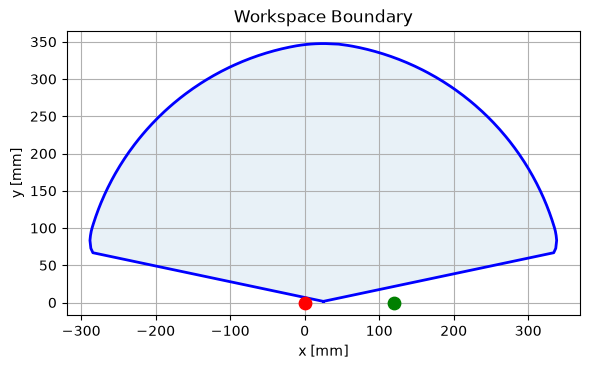

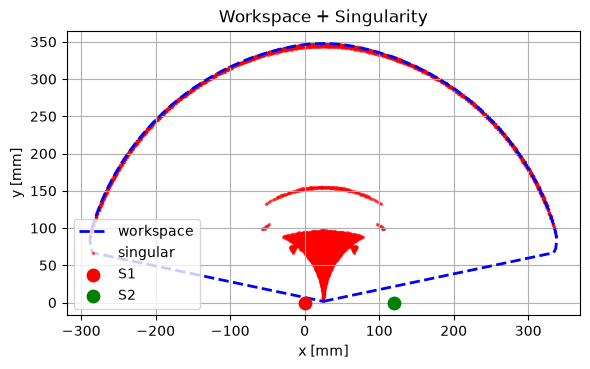

I_total : 0.0404 kg·m²
α       : 10 rad/s²
τ demand: 4.12 kg·cm
minimum servo rating: 8.23


In [30]:
analyse(
    base = 50, # mm
    proximal = 200, # mm
    distal = 150, # mm
    payload = 0.25, # kg
    alpha = 10 # mm / sec^2
)